# Lokta-Volterra, predator-prey model

## Set-up

The first step of running a Julia program is to load the external libraries one will be using. We do this with a `using` statement.

In [ ]:
using AlgebraicABMs, Catlab, AlgebraicRewriting, DataMigrations 
using Test, Random
using Catlab.Graphics.Graphviz: Attributes, Statement, Node 
using Catlab.Graphics.Graphviz 
ENV["JULIA_DEBUG"] = "AlgebraicABMs"; 

# We can also define some shorthand for some long function names
const hom = homomorphism 
const homs = homomorphisms 
const Var = AttrVar;
Random.seed!(123); # hidemodelsList

## Schema

Defining a schema is stating what data is required to specify a state of the
simulation at some point in time. In AlgebraicJulia, this is done via declaring
a `Presentation`, i.e. a database schema. Objects (`Ob`, or tables) are types of
entities. Homs (`Hom`, or foreign keys) are functional relationships between the
aforementioned entities. AttrTypes are placeholders for Julia types, which are
assigned to objects via attributes (`Attr`).

The schema below *extends* the schema for symmetric graphs, which consists in
two tables (`E` and `V`, for edges and vertices), a hom `inv` which pairs each 
edge with its symmetric dual edge, and homs (`src`, `tgt`) which
relate the edges to the vertices. This extension is indicated by the subtype 
operator `<: SchSymmetricGraph`. Here we add a notion of cardinal direction to a 
symmetric graph, encoding that left and right are inverses and that four 
rotations does nothing. Edges are all assigned a cardinal direction.

These schemas don't yet have the capacity to express constraints such as 
"each vertex has exactly four incident edges, one of each cardinal direction",
but future versions of Catlab will be able to do this. For now, this is a 
property we will enforce when we create grids.

In [2]:
@present SchGrid <: SchSymmetricGraph begin 
  Direction::Ob
  dir::Hom(E, Direction)
  left::Hom(Direction, Direction)
  right::Hom(Direction, Direction)
  left⋅left⋅left⋅left == id(Direction)
  right⋅left == id(Direction)
  left⋅right == id(Direction)
  inv⋅dir == dir⋅left⋅left
end;
modelsList
@acset_type Grid(SchGrid) <: AbstractSymmetricGraph; # Create LV datatype

We now want to allow wolves and sheep to live on the vertices of this grid as 
well as be oriented in a particular direction.

In [3]:
@present SchWS <: SchGrid begin 
  (Wolf, Sheep)::Ob
  wolf_loc::Hom(Wolf, V)
  sheep_loc::Hom(Sheep, V)
  wolf_dir::Hom(Wolf,Direction)
  sheep_dir::Hom(Sheep,Direction)
end;

A set of time counters are associated with vertices via "countdown"
which tracks how long it takes until the grass is ready to eat at a location. 

In [4]:
@present SchWSG <: SchWS begin
  Time::Ob
  countdown::Hom(Time, V)
end;

The animals have an "energy", drained by moving and reproduction, gained via 
eating food.

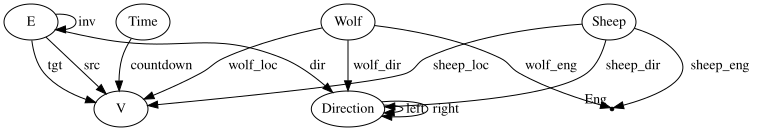

In [5]:
@present SchLV <: SchWSG begin
  Eng::AttrType
  wolf_eng::Attr(Wolf, Eng)
  sheep_eng::Attr(Sheep, Eng)
end;

@acset_type LV(SchLV){Int} <: AbstractSymmetricGraph # Create LV datatype

to_graphviz(SchLV; prog="dot")

We can further extend this schema with an additional attribute of (x,y) 
coordinates for every vertex. This is nice for visualization but is otherwise 
unnecessary when doing the actual agent-based modeling. We can also add names 
to the directions for convenience.

So what we will do is *build* our model with the LV schema and then *run* our 
model with the LV_viz schema.

In [6]:
@present SchLV_Viz <: SchLV begin
  (Coord, Name)::AttrType
  coord::Attr(V, Coord)
  dirname::Attr(Direction, Name)
end

@acset_type LV_Viz(SchLV_Viz){Int, Tuple{Int,Int}, String} <: AbstractSymmetricGraph

const LV′ = Union{LV, LV_Viz};

## Initializing and visualizing world states

To help us create initial states for simulations, a (hidden) helper function 
that makes an n × n grid with periodic boundary conditions. One edge in each 
cardinal direction originates at every point.

In [7]:
function create_grid(n::Int)::LV_Viz
  lv, coords = LV_Viz(), Dict{Pair{Int,Int}, Int}() 
  N, W, S, E = add_parts!(lv, :Direction, 4; left=[2,3,4,1], right=[4,1,2,3],
                          dirname=["N","W","S","E"]) 
  for i in 0:n-1, j in 0:n-1 
    coords[i=>j] = add_vertex!(lv; coord=(i,j)) 
    add_parts!(lv, :Time, max(0, rand(-30:30)); countdown=coords[i=>j]) 
  end 
  for i in 0:n-1, j in 0:n-1 
    _, e = add_edge!(lv, coords[i=>j], coords[mod(i + 1, n)=>j]; dir=E) 
    lv[lv[e,:inv], :dir] = W 
    _, e = add_edge!(lv, coords[i=>j], coords[i=>mod(j + 1, n)]; dir=N) 
    lv[lv[e,:inv], :dir] = S 
  end 
  return lv 
end; 

To initialize a state of the world with sheep and wolves, we also accept 
parameters which indicate the fraction of spaces that are 
populated with that animal.

In [8]:
function initialize(n::Int, sheep::Float64, wolves=nothing)::LV_Viz
  wolves = isnothing(wolves) ? sheep : wolves 
  grid = create_grid(n) 
  args = [(sheep, :Sheep, :sheep_loc, :sheep_eng, :sheep_dir), 
    (wolves, :Wolf, :wolf_loc, :wolf_eng, :wolf_dir)] 
  for (n_, name, loc, eng, d) in args, _ in 1:round(Int, n_ * n^2) 
    dic = Dict([eng => 5, loc => rand(vertices(grid)),  d => rand(1:4)]) 
    add_part!(grid, name; dic...) 
  end 
  return grid 
end; 

Some visualization code below will allow us to see states of the world. Edges 
are left implicit (we know from how the graphs were constructed that there are 
edges between every pair of adjacent vertices).

In [9]:

supscript_d = Dict(zip("1234567890xyzabcd", "¹²³⁴⁵⁶⁷⁸⁹⁰ˣʸᶻᵃᵇᶜᵈ")) # hide
supscript(x::String) = join([get(supscript_d, c, c) for c in x]); # hide

function view_LV(p::LV′, pth=tempname(); name="G", title="")
  pstr = ["$(i),$(j)!" for (i, j) in p[:coord]] 
  stmts = Statement[] 
  for s in 1:nv(p) 
    gv = length(incident(p, s, :countdown)) 
    col = gv == 0 ? "lightgreen" : "tan" 
    push!(stmts, Node("v$s", Attributes( 
      :label => gv == 0 ? "" : string(gv), :shape => "circle", 
      :color => col, :pos => pstr[s]))) 
  end 
  d = Dict("E" => (1, 0), "N" => (0, 1), "S" => (0, -1), "W" => (-1, 0)) 

  args = [(:true, :Wolf, :wolf_loc, :wolf_eng, :wolf_dir), 
    (false, :Sheep, :sheep_loc, :sheep_eng, :sheep_dir)] 

  for (is_wolf, prt, loc, eng, dr) in args, agent in parts(p, prt) 
    e = only(incident(p, p[agent, loc], :src) ∩ incident(p, p[agent, dr], :dir)) 
    dx, dy = d[p[e, [:dir, :dirname]]] 
    (sx, sy) = p[src(p, e), :coord] 

    L, R = 0.25, 0.1 
    wx = sx + L * dx + R * rand() 
    wy = sy + L * dy + R * rand() 
    ID = "$(is_wolf ? :w : :s)$agent" 
    append!(stmts, [Node(ID, Attributes(
      :label => "$agent" * supscript("$(p[agent,eng])"), 
      :shape => "square", :width => "0.3px", :height => "0.3px", :fixedsize => "true", 
      :pos => "$(wx),$(wy)!", :color => is_wolf ? "red" : "lightblue"))]) 
  end 

  g = Graphviz.Digraph(name, Statement[stmts...]; prog="neato", 
    graph_attrs=Attributes(:label => title, :labelloc => "t"), 
    node_attrs=Attributes(:shape => "plain", :style => "filled")) 
  open(pth, "w") do io 
    show(io, "image/svg+xml", g) 
  end 
  return g 
end; 

We can use this to visualize an example

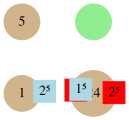

In [10]:
init = initialize(2, 0.5)
view_LV(init)

## Data Migration Functors

The schema LV has a certain symmetry between wolves and sheep, and this 
symmetry can be used to take *instances* of the schema (i.e. world states) and 
swap the wolves and the sheep. This is helpful for avoiding repeating work: 
there are certain actions that wolves and sheep share, so, by using this data 
migration, we can define them in terms of sheep and then migrate along `F` to 
obtain the analogous actions for wolves.

In [11]:
F = Migrate(
  Dict(:Sheep => :Wolf, :Wolf => :Sheep),
  Dict([:sheep_loc => :wolf_loc, :wolf_loc => :sheep_loc,
    :sheep_eng => :wolf_eng, :wolf_eng => :sheep_eng, :countdown => :countdown,
    :sheep_dir => :wolf_dir, :wolf_dir => :sheep_dir,]), SchLV, LV);

We ought to be able to take a state of the world (with no coordinate information)
and obtain a state of the world with coordinates (the canonical way to do this 
is to assign "variables" for the values of the coordinates).

In [12]:
Viz = Migrate(SchLV, LV, SchLV_Viz, LV_Viz; delta=false);

## Representables

We want to say "give me a sheep" or "give me a 
sheep and a wolf that are on the same vertex" and have it automatically specify 
the remaining information in the most generic way possible. The `@acset_colim` 
macro is perfect for exactly this. In order to use 
that macro, we need to precompute the `yoneda_cache`.

In [13]:
yLV = yoneda_cache(LV);
I = LV() # Empty agent type
S = @acset_colim yLV begin s::Sheep end # Generic sheep agent
E = @acset_colim yLV begin e::E end # Generic edge
Eng = @acset_colim yLV begin e::Eng end # Free floating energy unit
D = @acset_colim yLV begin D::Direction end # Generic cardinal directions
W = F(S) # Generic wolf agent, obtained via the swapping `F` data migration
G = @acset_colim yLV begin v::V end; # Generic grass agent (i.e. vertex)

## Rules 

We have finished specifying what makes up a simulation state, and next is to 
define what sorts of transitions are possible. This is done by declaring 
rewrite rules.

### Rotating 

Our first action that is possible for sheep (and wolves) is rotation. Animals 
will, with some probability, change their orientation. This is a rewrite rule 
which only modifies an attribute rather than changing any combinatorial data, 
so rather than the usual span `L ← I → R` data required we simply put in a 
single ACSet along with an `expr` dictionary which states how attributes 
change.

In [15]:
DVS_N, DVS_E, DVS_W, _ = homs(D ⊕ G ⊕ Eng, S; initial=(Eng=[Var(1)],))
sheep_rl = Rule(DVS_N, DVS_E);
sheep_rr = Rule(DVS_N, DVS_W);

ex = @acset_colim yLV begin
  e::E; s::Sheep;
  sheep_loc(s)==src(e); sheep_eng(s)==100; dir(e)==left(sheep_dir(s))
end;

expected = copy(ex); 
expected[:sheep_dir] = ex[1, :dir] # rotate right aligns the sheep w/ the edge

@test is_isomorphic(rewrite(sheep_rl, ex), expected)

Test Passed

#### Test Rotation

In [16]:
ex = @acset_colim yLV begin
  e::E; s::Sheep;
  sheep_loc(s)==src(e); sheep_eng(s)==100; dir(e)==left(sheep_dir(s))
end;

expected = copy(ex); 
expected[:sheep_dir] = ex[1, :dir] # rotate right aligns the sheep w/ the edge

@test is_isomorphic(rewrite(sheep_rl, ex), expected)

Test Passed

### Moving Forward

In [17]:
s_fwd_l = @acset_colim yLV begin
  e::E; s::Sheep
  sheep_loc(s) == src(e)
  dir(e) == sheep_dir(s)
end

s_fwd_r = @acset_colim yLV begin
  e::E; s::Sheep; sheep_loc(s) == tgt(e); dir(e) == sheep_dir(s)
end;

sheep_fwd_rule = Rule(first(homs(E, s_fwd_l; monic=true)),
                      last(homs(E,  s_fwd_r; monic=true)),
                      expr=(Eng=[((eₛ,),) -> eₛ - 1],));

#### Test Moving Forward

In [18]:
ex = @acset_colim yLV begin
  (e1,e2)::E; (s::Sheep)
  src(e2)==tgt(e1); sheep_loc(s)==src(e1)
  sheep_eng(s)==10
  sheep_dir(s)==dir(e1); dir(e1)==left(dir(e2))
end
expected = copy(ex); 
expected[1, :sheep_loc] = ex[1, :tgt]
expected[1, :sheep_eng] = 9

@test is_isomorphic(expected, rewrite(sheep_fwd_rule, ex))

Test Passed

### Sheep Eat Grass

In [19]:
s_eat_N = @acset_colim yLV begin 
  s::Sheep; t::Time; countdown(t) == sheep_loc(s) 
end
s_eat_L = @acset_colim yLV begin s::Sheep;  end;
s_eat_R = deepcopy(s_eat_L)
add_parts!(s_eat_R, :Time, 30; countdown=1)
se_left = hom(G⊕D, s_eat_L; initial=(Direction=1:4,))
se_right = hom(G⊕D, s_eat_R;  initial=(Direction=1:4,))
se_nac = hom(s_eat_L, s_eat_N)
se_rule = Rule(se_left, se_right; 
               ac=[AppCond(se_nac, false)], expr=(Eng=[((vₛ,),) -> vₛ + 4],));

#### Test Sheep Eat Grass

In [20]:
ex = @acset_colim yLV begin
  e::E; s::Sheep; t::Time
  dir(e)==sheep_dir(s); countdown(t)==src(e);
  sheep_loc(s)==tgt(e); sheep_eng(s) == 3
end

expected = copy(ex)
add_parts!(expected, :Time, 30; countdown=2)
expected[1,:sheep_eng] = 7
@test is_isomorphic(expected, rewrite(se_rule, ex))

Test Passed

### Wolves Eat Sheep

In [21]:
w_eat_l = @acset_colim yLV begin
  s::Sheep; w::Wolf; sheep_loc(s) == wolf_loc(w)
end;

we_left = hom(G⊕D⊕D, w_eat_l; initial=(Direction=Dict(1=>1, 5=>5),))
we_right = hom(G⊕D⊕D, D⊕W; initial=(Direction=Dict(1=>1, 5=>5),))
we_rule = Rule(we_left, we_right; 
               expr=(Eng=[((vₛ, vᵩ),) -> vᵩ + 20],));

#### Test Wolves Eat Sheep

In [22]:
ex = @acset_colim yLV begin 
  (s::Sheep); (w::Wolf); (e::E); (t1,t2,t3)::Time
  countdown(t1)==src(e); countdown(t2)==src(e); countdown(t3)==tgt(e)
  sheep_dir(s)==left(wolf_dir(w))
  sheep_dir(s)==right(dir(e))
  sheep_eng(s)==3; wolf_eng(w)==16
  sheep_loc(s)==tgt(e); wolf_loc(w)==tgt(e)
end

expected = copy(ex)
expected[1, :wolf_eng] = 36
rem_part!(expected, :Sheep, 1)

@test is_isomorphic(rewrite(we_rule, ex), expected)

Test Passed

### Sheep Starvation

In [23]:
s_die_l = @acset_colim yLV begin s::Sheep; sheep_eng(s) == 0 end;
sheep_die_rule = Rule(hom(G⊕D, s_die_l; any=true), id(G⊕D));

#### Test Sheep Starvation

In [24]:
ex = @acset_colim yLV begin 
  s::Sheep; w::Wolf; (t,t2)::Time
  countdown(t)==sheep_loc(s); countdown(t2)==wolf_loc(w)
  sheep_eng(s)==0; wolf_eng(w)==10; sheep_dir(s) == right(wolf_dir(w))
end
expected = copy(ex)
rem_part!(expected, :Sheep, 1)

@test is_isomorphic(rewrite(sheep_die_rule,ex), expected)

Test Passed

### Sheep Reproduction

In [25]:
s_reprod_r = @acset_colim yLV begin
  (x, y)::Sheep; sheep_loc(x) == sheep_loc(y); sheep_dir(x)==sheep_dir(y)
end;

sheep_reprod_rule = Rule(
  hom(G⊕D, S; any=true),
  hom(G⊕D, s_reprod_r; any=true);
  expr=(Dir=fill(vs->only(vs) ,2), 
        Eng=fill(vs -> round(Int, vs[1] / 2, RoundUp), 2),)
);


#### Test Sheep Reproduction

In [26]:
ex = @acset_colim yLV begin 
  s::Sheep; w::Wolf; t::Time
  countdown(t)==sheep_loc(s);
  sheep_eng(s)==10; wolf_eng(w)==20; sheep_dir(s) == right(wolf_dir(w))
end

expected = copy(ex)
add_part!(expected,:Sheep)
expected[:sheep_eng] = [5, 5]
expected[:sheep_loc] = fill(ex[1,:sheep_loc], 2)
expected[:sheep_dir] = fill(ex[1,:sheep_dir], 2)

m = hom(pattern(sheep_reprod_rule),ex)
can_match(sheep_reprod_rule, m)
@test is_isomorphic(rewrite(sheep_reprod_rule,ex),expected)

Test Passed

### Grass Increments

In [27]:
g_inc_L = @acset_colim yLV begin t::Time end
rem_time = hom(G, g_inc_L)
g_inc_rule = Rule(rem_time, id(G));

#### Test Grass Increments

In [28]:
ex = @acset_colim yLV begin
  e::E; t::Time; countdown(t) == tgt(e)
end

@test is_isomorphic(rewrite(g_inc_rule, ex), E)

Test Passed

## Add Timers to the Rules

With our possible actions defined, we now need to provide enough information 
for a simulator to execute the actions in time. A simple way of doing this is 
to add an exponential waiting time to each action.

In [ ]:
MkRule(args) = ABMRule(args[1], args[2], ContinuousHazard(args[3]))

rules = MkRule.([
  (:SheepRotateRight, sheep_rr , 1.), 
  (:SheepRotateLeft, sheep_rl , 1.), 
  (:SheepMoveFwd, sheep_fwd_rule, 0.5),
  (:WolfRotateRight, F(sheep_rr), 1.), 
  (:WolfRotateLeft, F(sheep_rl),1.), 
  (:WolfMoveFwd, F(sheep_fwd_rule), .25),
  (:SheepStarve, sheep_die_rule, 0.001), 
  (:WolfStarve, F(sheep_die_rule), 0.001),
  (:SheepReprod, sheep_reprod_rule, 0.5), 
  (:WolfReprod, F(sheep_reprod_rule), 20), 
  (:GrassGrow, g_inc_rule , 1.)])

## Make the Model

In [30]:
abm = ABM(rules) # this is defined for SchLV, not SchLV_Viz
abm_viz = Viz(abm);

## Run the model

In [ ]:
init = initialize(2, 0.25)

res = run!(abm_viz, init; maxevent=3)
imgs = view(res, view_LV);

The first image is our starting point:

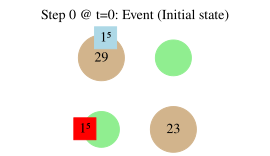

In [32]:
imgs[1]

Then the first event:

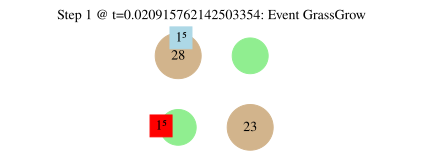

In [33]:
imgs[2]

Then the second:

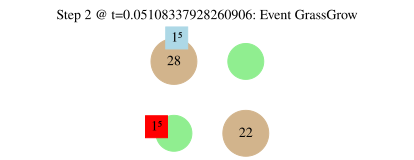

In [34]:
imgs[3]

And the third:

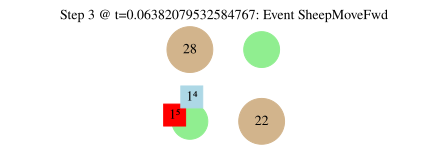

In [35]:
imgs[4]